In [1]:
import os
import mne
import numpy as np
import os.path as op
import matplotlib.pyplot as plt
from mne.preprocessing import (ICA, create_ecg_epochs, annotate_muscle_zscore, annotate_movement, 
                               compute_average_dev_head_t, create_eog_epochs, find_eog_events, find_ecg_events)

from collections import Counter

In [2]:
# Set pathway and doucment location
s = 'p018'
v = 'Final'
path = f'/Users/immlab/Desktop/IMM-Lab/Gabor_MEG/Prepro'
meg_dir = op.join(path, f'{s}_MEG_ENS_Gabor')

# Read the raw file for each block

In [17]:
# Read in all raw MEG data (8 Blocks)
raw1 = mne.io.read_raw_fif(op.join(meg_dir,f'{s}_meg_ens_Gabor_01_raw.fif'), preload=True)
raw2 = mne.io.read_raw_fif(op.join(meg_dir,f'{s}_meg_ens_Gabor_02_raw.fif'), preload=True)
raw3 = mne.io.read_raw_fif(op.join(meg_dir,f'{s}_meg_ens_Gabor_03_raw.fif'), preload=True)
raw4 = mne.io.read_raw_fif(op.join(meg_dir,f'{s}_meg_ens_Gabor_04_raw.fif'), preload=True)
raw5 = mne.io.read_raw_fif(op.join(meg_dir,f'{s}_meg_ens_Gabor_05_raw.fif'), preload=True)
raw6 = mne.io.read_raw_fif(op.join(meg_dir,f'{s}_meg_ens_Gabor_06_raw.fif'), preload=True)
raw7 = mne.io.read_raw_fif(op.join(meg_dir,f'{s}_meg_ens_Gabor_07_raw.fif'), preload=True)
raw8 = mne.io.read_raw_fif(op.join(meg_dir,f'{s}_meg_ens_Gabor_08_raw.fif'), preload=True)

Opening raw data file /Users/immlab/Desktop/IMM-Lab/Gabor_MEG/Prepro/p018_MEG_ENS_Gabor/p018_meg_ens_Gabor_01_raw.fif...
    Read a total of 13 projection items:
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
    Range : 32000 ... 436999 =     32.000 ...   436.999 secs
Ready.
Reading 0 ... 404999  =      0.000 ...   404.999 secs...
Opening raw data file /Users/immlab/Desktop/IMM-Lab/Gabor_MEG/Prepro/p018_ME

In [4]:
# Calculate duration of each block
durations = []
for i, raw in enumerate([raw1, raw2, raw3, raw4, raw5, raw6, raw7, raw8], 1):
    duration = raw.times.max()  # or simply raw.times.max()
    durations.append(duration)
    print(f"Block {i} duration: {duration:.3f} seconds")

total_time = sum(durations)
print(f"\nTotal recording time: {total_time:.3f} seconds")
print(f"Total recording time: {total_time/60:.2f} minutes")

Block 1 duration: 404.999 seconds
Block 2 duration: 400.999 seconds
Block 3 duration: 404.999 seconds
Block 4 duration: 398.999 seconds
Block 5 duration: 401.999 seconds
Block 6 duration: 409.999 seconds
Block 7 duration: 401.999 seconds
Block 8 duration: 403.999 seconds

Total recording time: 3227.992 seconds
Total recording time: 53.80 minutes


# Calculate the time window for each block and crop it into 10 divisible segments.

In [5]:
# Store information about each recording
recording_info = []
cropped_raws = []
boundary_threshold = 2
make_divisible_by=10
# Step 1: Analyze each recording
for i, raw in enumerate ([raw1, raw2, raw3, raw4, raw5, raw6, raw7, raw8], 1):
    # Find events
    events = mne.find_events(raw, stim_channel='STI101',shortest_event=1/raw.info['sfreq'])
       
    # Calculate timing information
    original_duration = raw.times[-1]  # Last time point
    original_tmin = raw.times[0]       # First time point (usually 0)
    original_tmax = raw.times[-1]      # Last time point
    
    # First and last trigger times (in seconds)
    First_trigger = (events[0, 0] - raw.first_samp) / raw.info['sfreq']
    Last_trigger = (events[-1, 0] - raw.first_samp) / raw.info['sfreq']
    
    # Calculate boundaries
    start_boundary = First_trigger - original_tmin
    end_boundary = original_tmax - Last_trigger
    
    # Determine cropping parameters
    crop_start = start_boundary > boundary_threshold
    crop_end = end_boundary > boundary_threshold
    
    # Calculate new tmin and tmax
    if crop_start:
        new_tmin = First_trigger - boundary_threshold
    else:
        new_tmin = original_tmin
        
    if crop_end:
        new_tmax = Last_trigger + boundary_threshold
    else:
        new_tmax = original_tmax
        
    new_duration = new_tmax - new_tmin
    
    # Store information
    info = {'recording_num': i,'original_duration': original_tmax,'original_tmin': original_tmin,'original_tmax': original_tmax,
            'first_trigger_time': First_trigger,'last_trigger_time': Last_trigger,'start_boundary': start_boundary,'end_boundary': end_boundary,
            'crop_start': crop_start,'crop_end': crop_end,'new_tmin': new_tmin,'new_tmax': new_tmax,'new_duration': new_duration,
            'time_saved': original_tmax - new_duration}
    recording_info.append(info)
    
    # Print analysis
    print(f"  Original duration: {original_tmax:.2f}s")
    print(f"  First trigger at: {First_trigger:.2f}s (boundary: {start_boundary:.2f}s)")
    print(f"  Last trigger at: {Last_trigger:.2f}s (boundary: {end_boundary:.2f}s)")
    # Decision logic
    if start_boundary <= boundary_threshold:
        print(f"  Start boundary ({start_boundary:.2f}s) <= threshold ({boundary_threshold}s): KEEPING original start")
    if end_boundary <= boundary_threshold:
        print(f"  End boundary ({end_boundary:.2f}s) <= threshold ({boundary_threshold}s): KEEPING original end")
        
    print(f"  Crop start: {crop_start} | Crop end: {crop_end}")
    print(f"  New duration: {new_duration:.2f}s (saved: {info['time_saved']:.2f}s)")
    print("="*60)

240 events found on stim channel STI101
Event IDs: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 64]
  Original duration: 405.00s
  First trigger at: 7.71s (boundary: 7.71s)
  Last trigger at: 401.91s (boundary: 3.09s)
  Crop start: True | Crop end: True
  New duration: 398.20s (saved: 6.80s)
236 events found on stim channel STI101
Event IDs: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 64]
  Original duration: 401.00s
  First trigger at: 1.30s (boundary: 1.30s)
  Last trigger at: 397.09s (boundary: 3.91s)
  Start boundary (1.30s) <= threshold (2s): KEEPING original start
  Crop start: False | Crop end: True
  New duration: 399.09s (saved: 1.91s)
239 events found on stim channel STI101
Event IDs: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 64]
  Original duration: 405.00s
  First trigger at: 2.03s (boundary: 2.03s)
  Last trigger at: 394.36s (boundary: 10.64s)
  Crop start: True | Crop end: True
  New duration: 396.33s (saved: 8.

In [6]:
# Step 2: Calculate total duration and adjust if needed
total_original_duration = sum(info['original_duration'] for info in recording_info)
total_new_duration = sum(info['new_duration'] for info in recording_info)

print("Sum duration")
print("="*40)
print(f"Total original duration: {total_original_duration:.2f}s")
print(f"Total new duration: {total_new_duration:.2f}s")
#print(f"Total time saved: {total_original_duration - total_new_duration:.2f}s")

# Step 3: Make duration divisible by target number
if make_divisible_by:
    remainder = total_new_duration % make_divisible_by
    if remainder != 0:
        adjustment_needed = make_divisible_by - remainder
        print(f"\nAdjusting for divisibility by {make_divisible_by}:")
        print(f"  Current total: {total_new_duration:.2f}s")
        print(f"  Need to add: {adjustment_needed:.2f}s")
        
        # Distribute the adjustment across recordings that have room to extend
        adjustable_recordings = []
        for i, info in enumerate(recording_info):
            # Check if recording can be extended (has room at start or end)
            can_extend_start = info['new_tmin'] > info['original_tmin']
            can_extend_end = info['new_tmax'] < info['original_tmax']
            
            if can_extend_start or can_extend_end:
                max_extension_start = info['new_tmin'] - info['original_tmin'] if can_extend_start else 0
                max_extension_end = info['original_tmax'] - info['new_tmax'] if can_extend_end else 0
                max_extension_total = max_extension_start + max_extension_end
                
                adjustable_recordings.append({'index': i,'info': info,
                    'can_extend_start': can_extend_start,'can_extend_end': can_extend_end,
                    'max_extension_start': max_extension_start,'max_extension_end': max_extension_end,'max_extension_total': max_extension_total})
        
        if adjustable_recordings:
            # Calculate total available extension
            total_available_extension = sum(rec['max_extension_total'] for rec in adjustable_recordings)
            
            if total_available_extension >= adjustment_needed:
                print(f"  Available extension capacity: {total_available_extension:.2f}s")
                
                # Distribute adjustment proportionally
                for rec in adjustable_recordings:
                    if rec['max_extension_total'] > 0:
                        proportion = rec['max_extension_total'] / total_available_extension
                        rec_adjustment = min(adjustment_needed * proportion, rec['max_extension_total'])
                        
                        # Decide where to add the time (prioritize end extension)
                        if rec['can_extend_end'] and rec['max_extension_end'] >= rec_adjustment:
                            rec['info']['new_tmax'] += rec_adjustment
                            print(f"    Recording {rec['info']['recording_num']}: extended end by {rec_adjustment:.2f}s")
                        elif rec['can_extend_start'] and rec['max_extension_start'] >= rec_adjustment:
                            rec['info']['new_tmin'] -= rec_adjustment
                            print(f"    Recording {rec['info']['recording_num']}: extended start by {rec_adjustment:.2f}s")
                        else:
                            # Split between start and end
                            end_ext = min(rec_adjustment / 2, rec['max_extension_end'])
                            start_ext = min(rec_adjustment - end_ext, rec['max_extension_start'])
                            
                            if end_ext > 0:
                                rec['info']['new_tmax'] += end_ext
                            if start_ext > 0:
                                rec['info']['new_tmin'] -= start_ext
                            
                            print(f"    Recording {rec['info']['recording_num']}: extended start by {start_ext:.2f}s, end by {end_ext:.2f}s")
                        
                        # Update duration
                        rec['info']['new_duration'] = rec['info']['new_tmax'] - rec['info']['new_tmin']
                
                # Recalculate total duration
                total_new_duration = sum(info['new_duration'] for info in recording_info)
                print(f"  New total duration: {total_new_duration:.2f}s")
                print(f"  Divisible by {make_divisible_by}: {total_new_duration % make_divisible_by == 0}")
                
            else:
                print(f"  WARNING: Not enough extension capacity ({total_available_extension:.2f}s) for required adjustment ({adjustment_needed:.2f}s)")
                print(f"  Will proceed with current duration (not divisible by {make_divisible_by})")
        else:
            print(f"  WARNING: No recordings can be extended to achieve divisibility")
            print(f"  All recordings are already at their original boundaries")
            print(f"  Will proceed with current duration (not divisible by {make_divisible_by})")


Sum duration
Total original duration: 3227.99s
Total new duration: 3185.19s

Adjusting for divisibility by 10:
  Current total: 3185.19s
  Need to add: 4.81s
  Available extension capacity: 42.80s
    Recording 1: extended end by 0.76s
    Recording 2: extended end by 0.21s
    Recording 3: extended end by 0.97s
    Recording 4: extended end by 0.29s
    Recording 5: extended end by 0.74s
    Recording 6: extended end by 1.37s
    Recording 7: extended end by 0.32s
    Recording 8: extended end by 0.15s
  New total duration: 3190.00s
  Divisible by 10: True


In [7]:
# Step 4: Apply cropping
print("APPLYING CROPPING")
print("="*40)

for i, (raw, info) in enumerate(zip([raw1, raw2, raw3, raw4, raw5, raw6, raw7, raw8], recording_info)):
    print(f"\nCropping Recording {info['recording_num']}...")
    print(f"  Cropping from {info['new_tmin']:.2f}s to {info['new_tmax']:.2f}s")
    try:
        # Create a copy and crop it
        raw_cropped = raw.copy()
        raw_cropped.crop(tmin=info['new_tmin'], tmax=info['new_tmax'])
        cropped_raws.append(raw_cropped)
        
        print(f"  ✓ Successfully cropped: {raw_cropped.times[-1]:.2f}s duration")
        
    except Exception as e:
        print(f"  ✗ Error cropping recording {info['recording_num']}: {e}")
        cropped_raws.append(raw)  # Keep original if cropping fails


APPLYING CROPPING

Cropping Recording 1...
  Cropping from 5.71s to 404.67s
  ✓ Successfully cropped: 398.97s duration

Cropping Recording 2...
  Cropping from 0.00s to 399.31s
  ✓ Successfully cropped: 399.31s duration

Cropping Recording 3...
  Cropping from 0.03s to 397.34s
  ✓ Successfully cropped: 397.31s duration

Cropping Recording 4...
  Cropping from 0.61s to 397.30s
  ✓ Successfully cropped: 396.69s duration

Cropping Recording 5...
  Cropping from 2.33s to 398.51s
  ✓ Successfully cropped: 396.17s duration

Cropping Recording 6...
  Cropping from 10.01s to 409.22s
  ✓ Successfully cropped: 399.22s duration

Cropping Recording 7...
  Cropping from 0.67s to 400.17s
  ✓ Successfully cropped: 399.50s duration

Cropping Recording 8...
  Cropping from 0.00s to 402.83s
  ✓ Successfully cropped: 402.83s duration


In [8]:
# Step 5: Final verification
final_total_duration = sum(raw.times[-1] for raw in cropped_raws)

print(f"\n" + "="*40)
print("FINAL RESULTS")
print("="*40)
print(f"Number of recordings processed: {len(cropped_raws)}")
print(f"Final total duration: {final_total_duration:.2f}s")
print(f"Divisible by {make_divisible_by}: {final_total_duration % make_divisible_by == 0}")
print(f"Total time saved: {total_original_duration - final_total_duration:.2f}s")

# Create summary info
cropping_info = {
    'total_original_duration': total_original_duration,
    'final_total_duration': final_total_duration,
    'time_saved': total_original_duration - final_total_duration,
    'recordings_info': recording_info,
    'boundary_threshold': boundary_threshold,
    'make_divisible_by': make_divisible_by,
    'is_divisible': final_total_duration % make_divisible_by == 0}


FINAL RESULTS
Number of recordings processed: 8
Final total duration: 3190.00s
Divisible by 10: False
Total time saved: 37.99s


In [9]:
# Start with first recording
raw_concatenated = cropped_raws[0].copy()

# Append each subsequent recording one by one
for raw_to_append in cropped_raws[1:]:
    raw_concatenated.append(raw_to_append)

# save new combined raw file
raw_concatenated.save(op.join(meg_dir,f'{s}_MEG_ENS_GABOR_raw.fif'), overwrite = True)

del raw1, raw2, raw3, raw4, raw5, raw6, raw7, raw8

Writing /Users/immlab/Desktop/IMM-Lab/Gabor_MEG/Prepro/p018_MEG_ENS_Gabor/p018_MEG_ENS_GABOR_raw.fif
Closing /Users/immlab/Desktop/IMM-Lab/Gabor_MEG/Prepro/p018_MEG_ENS_Gabor/p018_MEG_ENS_GABOR_raw.fif
Writing /Users/immlab/Desktop/IMM-Lab/Gabor_MEG/Prepro/p018_MEG_ENS_Gabor/p018_MEG_ENS_GABOR_raw-1.fif
Closing /Users/immlab/Desktop/IMM-Lab/Gabor_MEG/Prepro/p018_MEG_ENS_Gabor/p018_MEG_ENS_GABOR_raw-1.fif
[done]


In [21]:
del raw1, raw2, raw3, raw4, raw5, raw6, raw7, raw8

# Check the triggers / events from entire recording 

In [10]:
# Load your raw and empty room MEG data
raw = mne.io.read_raw_fif(op.join(meg_dir, f'{s}_meg_ens_Gabor_raw.fif'), preload=True)
#erm = mne.io.read_raw_fif(op.join(meg_dir, f'{s}_meg_ens_Gabor_erm_raw.fif'), preload=True)

print("="*60)
events = mne.find_events(raw, stim_channel='STI101', shortest_event=1/raw.info['sfreq']) # raw.info['sfreq']= 1000 Hz

Opening raw data file /Users/immlab/Desktop/IMM-Lab/Gabor_MEG/Prepro/p018_MEG_ENS_Gabor/p018_meg_ens_Gabor_raw.fif...
    Read a total of 13 projection items:
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
    Range : 37706 ... 1663705 =     37.706 ...  1663.705 secs
Ready.
Opening raw data file /Users/immlab/Desktop/IMM-Lab/Gabor_MEG/Prepro/p018_MEG_ENS_Gabor/p018_MEG_ENS_GABOR_raw-1.fif...
    Read a tota

In [11]:
# Setting event name
event_id = {'0_deg_1gabor': 1,'0_deg_4gabor': 2,'0_deg_4gabor_control': 3,'0_deg_16gabor': 4,'0_deg_16gabor_control': 5,
    '45_deg_1gabor': 6,'45_deg_4gabor': 7,'45_deg_4gabor_control': 8,'45_deg_16gabor': 9,'45_deg_16gabor_control': 10,
    '90_deg_1gabor': 11,'90_deg_4gabor': 12,'90_deg_4gabor_control': 13,'90_deg_16gabor': 14,'90_deg_16gabor_control': 15,
    '135_deg_1gabor': 16,'135_deg_4gabor': 17,'135_deg_4gabor_control': 18,'135_deg_16gabor': 19,'135_deg_16gabor_control': 20,
    'Catch':21,'key_press': 64}

# Create color scheme with similar colors for each orientation group
event_colors = {
    # 0 degree (1-5): Blues
    1: '#0f4c75',    # Dark blue (0_deg_1gabor)
    2: '#3282b8',    # Medium blue (0_deg_4gabor)
    3: '#bbe1fa',    # Light blue (0_deg_4gabor_control)
    4: '#1e5f8c',    # Blue (0_deg_16gabor)
    5: '#87ceeb',    # Sky blue (0_deg_16gabor_control)
    
    # 45 degree (6-10): Greens
    6: '#0d5016',    # Dark green (45_deg_1gabor)
    7: '#2d8f3f',    # Medium green (45_deg_4gabor)
    8: '#90ee90',    # Light green (45_deg_4gabor_control)
    9: '#1e6b26',    # Green (45_deg_16gabor)
    10: '#98fb98',   # Pale green (45_deg_16gabor_control)
    
    # 90 degree (11-15): Reds
    11: '#8b0000',   # Dark red (90_deg_1gabor)
    12: '#dc143c',   # Crimson (90_deg_4gabor)
    13: '#ffc0cb',   # Pink (90_deg_4gabor_control)
    14: '#b22222',   # Fire brick (90_deg_16gabor)
    15: '#ffb6c1',   # Light pink (90_deg_16gabor_control)
    
    # 135 degree (16-20): Purples
    16: '#4b0082',   # Indigo (135_deg_1gabor)
    17: '#8a2be2',   # Blue violet (135_deg_4gabor)
    18: '#dda0dd',   # Plum (135_deg_4gabor_control)
    19: '#663399',   # Purple (135_deg_16gabor)
    20: '#e6e6fa',   # Lavender (135_deg_16gabor_control)
    
    # Special events
    21: '#000000',   # Black (Catch_condition)
    64: '#808080'}    # Gray (key_press)

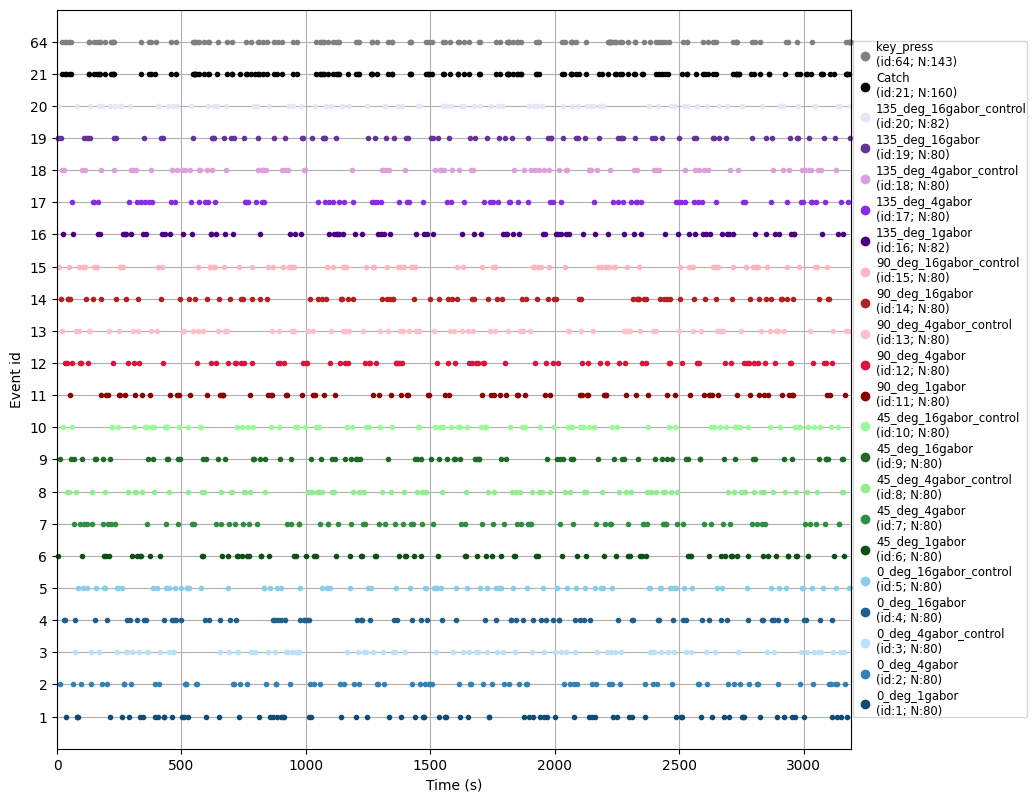

In [12]:
# Plot triggers (events)
Events_plot = mne.viz.plot_events(events, event_id=event_id, sfreq=raw.info["sfreq"], first_samp=raw.first_samp, color = event_colors )

Filtering raw data in 8 contiguous segments
Setting up band-pass filter from 1 - 80 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 80.00 Hz
- Upper transition bandwidth: 20.00 Hz (-6 dB cutoff frequency: 90.00 Hz)
- Filter length: 3301 samples (3.301 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.5s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    1.0s
[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    1.6s
[Parallel(n_jobs=1)]: Done 306 out of 306 | elapsed:    1.7s finished


Using matplotlib as 2D backend.


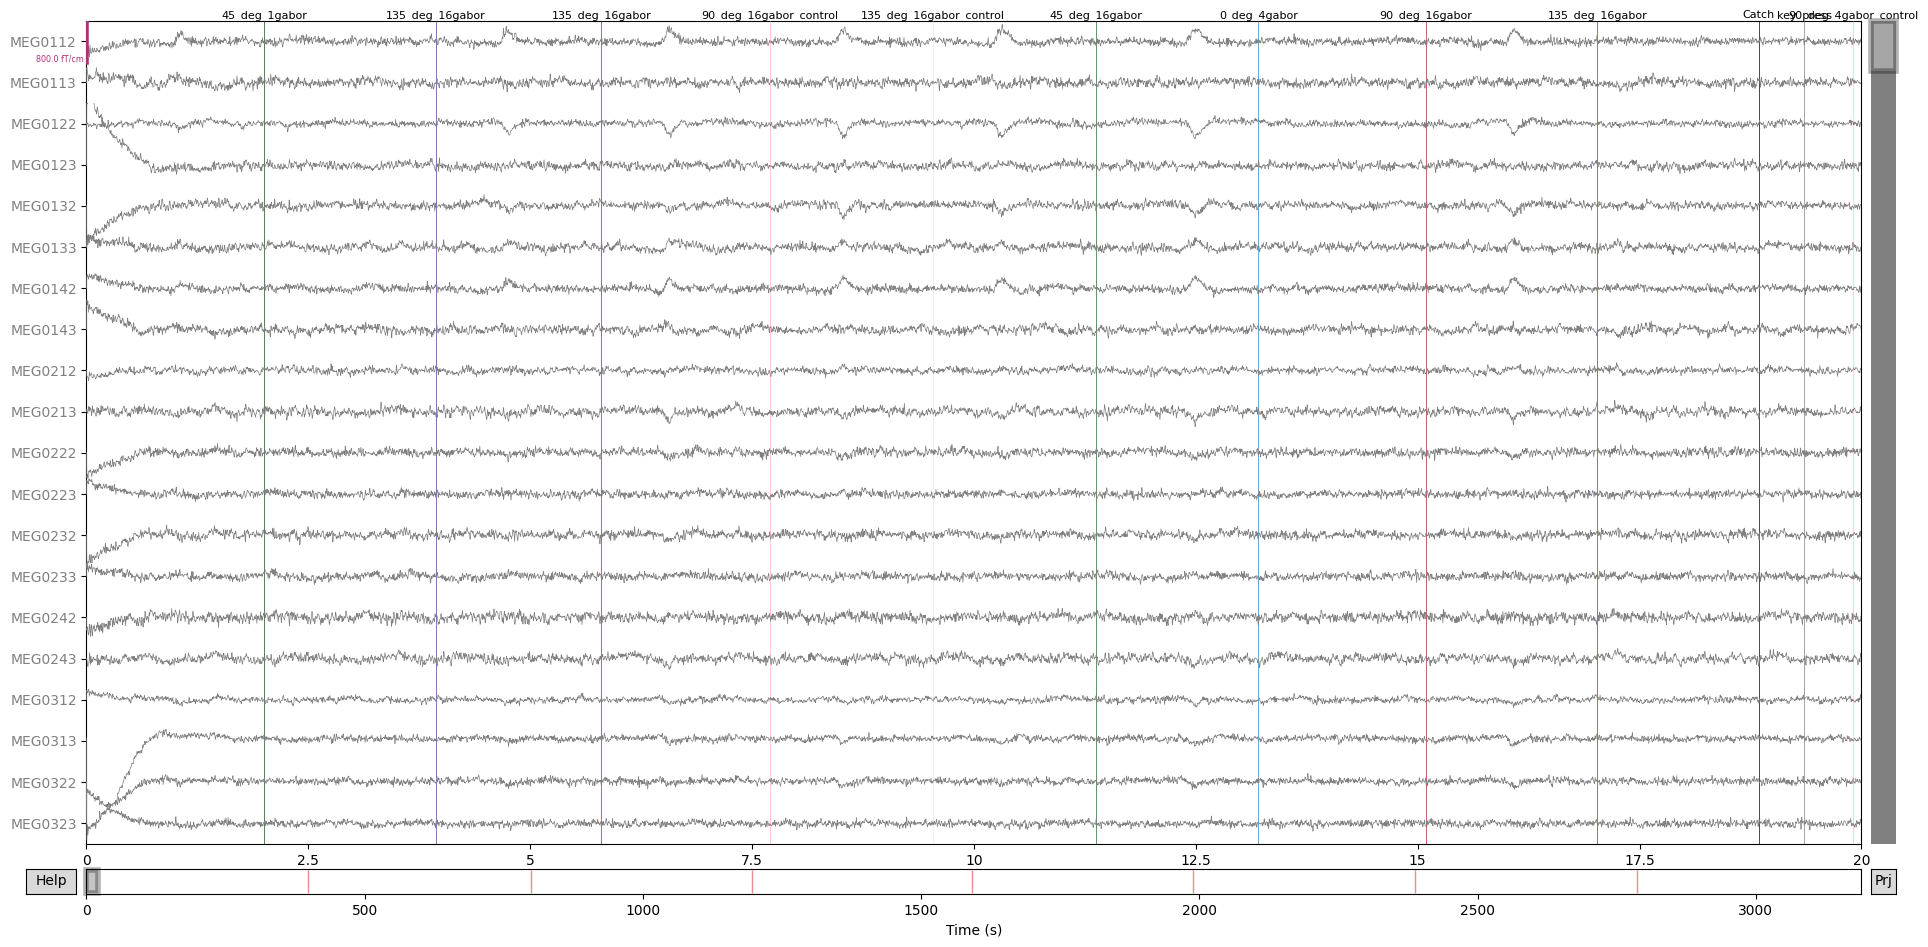

In [13]:
%matplotlib qt
raw.copy().filter(l_freq=1, h_freq=80).plot(events=events,duration = 20, color="gray", event_id=event_id, event_color=event_colors)

# Check each individual Block's triggers
### Block 1

In [18]:
print("="*60)
event_1 = mne.find_events(raw1, stim_channel='STI101', shortest_event=1/raw1.info['sfreq']) # raw.info['sfreq']= 1000 Hz
# Plot triggers (events)
Events_plot = mne.viz.plot_events(event_1, event_id=event_id, sfreq=raw1.info["sfreq"], first_samp=raw1.first_samp, color=event_colors)

240 events found on stim channel STI101
Event IDs: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 64]


In [ ]:
%matplotlib qt
# One-liner to create event_color dictionary
#event_color = {code: 'red' if code == 16 else 'black' for code in event_id.values()}
raw1.copy().filter(l_freq=1, h_freq=80).plot(events=event_1,duration = 20, color="gray",event_id=event_id,event_color=event_colors)

### Block 2

In [ ]:
print("="*60)
event_2 = mne.find_events(raw2, stim_channel='STI101', shortest_event=1/raw2.info['sfreq']) # raw.info['sfreq']= 1000 Hz
# Plot triggers (events)
Events_plot = mne.viz.plot_events(event_2, event_id=event_id, sfreq=raw2.info["sfreq"], first_samp=raw2.first_samp, color=event_colors)

In [ ]:
np.shape(event_2)
print(event_2)

### Navid's code

In [24]:
%matplotlib qt
# --- Extract timing from MNE events ---
event_times = events[:, 0]
event_codes = events[:, 2]
sfreq = raw.info['sfreq']
event_times_ms = event_times / sfreq * 1000
time_diffs = np.diff(event_times_ms)
# --- Set up x-axis and colors ---
#x = np.arange(len(time_diffs))
x = np.arange(1, len(time_diffs))
time_diffs_trimmed = time_diffs[1:]
bar_colors = []
for i in range(len(time_diffs)):
    curr_code = event_codes[i]
    next_code = event_codes[i + 1]
    if curr_code in stimulus_codes and next_code in response_codes:
        bar_colors.append('blue')  # Stimulus → Response
    elif curr_code in response_codes and next_code in stimulus_codes:
        bar_colors.append('red')   # Response → Stimulus
    else:
        bar_colors.append('gray')  # Other
# --- Create the plot ---
plt.figure(figsize=(len(x) / 5, 5))  # Wide enough to see x-axis labels
#plt.bar(x, time_diffs, width=0.3, color=bar_colors)
plt.bar(x, time_diffs_trimmed, width=0.3, color=bar_colors)
plt.xlabel("Event Index")
plt.ylabel("Time Between Events (ms)")
plt.title("Time Intervals Between Trigger Events")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
path = '/Users/navid300/Desktop/IMM_Lab/Amygdala_PREPRO/meg_data/'
meg_path = op.join(path, f'{participant_id}_2025_AMYG_meg_ens_raw')
#directory = os.path.dirname(meg_path)
filename = op.join(meg_path, f'{participant_id}_trigger_intervals.jpg')
plt.savefig(filename, dpi = 300)
# change participant id back to s

NameError: name 'stimulus_codes' is not defined

In [ ]:
%matplotlib qt
raw2.copy().filter(l_freq=1, h_freq=80).plot(events=event_2,duration = 20, color="gray",event_id=event_id, event_color = event_colors)

### Block 3

In [ ]:
print("="*60)
event_3 = mne.find_events(raw3, stim_channel='STI101', shortest_event=1/raw3.info['sfreq']) # raw.info['sfreq']= 1000 Hz
# Plot triggers (events)
Events_plot = mne.viz.plot_events(event_3, event_id=event_id, sfreq=raw3.info["sfreq"], first_samp=raw3.first_samp, color=event_colors)

In [ ]:
np.shape(event_3)
print(event_3)

In [ ]:
raw3.copy().filter(l_freq=1, h_freq=80).plot(events=event_3, duration = 20, color="gray", event_id=event_id, event_color = event_colors)

### Block 4

In [ ]:
print("="*60)
event_4 = mne.find_events(raw4, stim_channel='STI101', shortest_event=1/raw4.info['sfreq']) # raw.info['sfreq']= 1000 Hz
# Plot triggers (events)
Events_plot = mne.viz.plot_events(event_4, event_id=event_id, sfreq=raw4.info["sfreq"], first_samp=raw4.first_samp, color=event_colors)

In [ ]:
np.shape(event_4)
print(event_4)

In [ ]:
%matplotlib qt
raw4.copy().filter(l_freq=1, h_freq=80).plot(events=event_4,duration = 20, color="gray",event_id=event_id, event_color = event_colors)

### Block 5

In [ ]:
print("="*60)
event_5 = mne.find_events(raw5, stim_channel='STI101', shortest_event=1/raw5.info['sfreq']) # raw.info['sfreq']= 1000 Hz
# Plot triggers (events)
Events_plot = mne.viz.plot_events(event_5, event_id=event_id, sfreq=raw5.info["sfreq"], first_samp=raw5.first_samp, color=event_colors)

In [ ]:
raw5.copy().filter(l_freq=1, h_freq=80).plot(events=event_5,duration = 20, color="gray",event_id=event_id,event_color = event_colors)

### Block 6

In [ ]:
print("="*60)
event_6 = mne.find_events(raw6, stim_channel='STI101', shortest_event=1/raw6.info['sfreq']) # raw.info['sfreq']= 1000 Hz
# Plot triggers (events)
Events_plot = mne.viz.plot_events(event_6, event_id=event_id, sfreq=raw6.info["sfreq"], first_samp=raw6.first_samp, color=event_colors)

In [ ]:
%matplotlib qt
raw6.copy().filter(l_freq=1, h_freq=80).plot(events=event_6,duration = 20, color="gray",event_id=event_id, event_color=event_colors)

### Block 7

In [ ]:
print("="*60)
event_7 = mne.find_events(raw7, stim_channel='STI101', shortest_event=1/raw7.info['sfreq']) # raw.info['sfreq']= 1000 Hz
# Plot triggers (events)
Events_plot = mne.viz.plot_events(event_7, event_id=event_id, sfreq=raw7.info["sfreq"], first_samp=raw7.first_samp, color = event_colors)

In [ ]:
print(event_7)

In [ ]:
%matplotlib qt
raw7.copy().filter(l_freq=1, h_freq=80).plot(events=event_7,duration = 20, color="gray",event_id=event_id,  event_color=event_colors)

### Block 8

In [ ]:
print("="*60)
event_8 = mne.find_events(raw8, stim_channel='STI101', shortest_event=1/raw8.info['sfreq']) # raw.info['sfreq']= 1000 Hz
# Plot triggers (events)
Events_plot = mne.viz.plot_events(event_8, event_id=event_id, sfreq=raw8.info["sfreq"], first_samp=raw8.first_samp, color = event_colors)

In [ ]:
%matplotlib qt
raw8.copy().filter(l_freq=1, h_freq=80).plot(events=event_8,duration = 20, color="gray",event_id=event_id, event_color=event_colors)

# Remove repeat trigger

In [ ]:
print(" Check repeat triggers")
print("="*60)

# Step 1: Identify events with non-zero previous event ID (problematic overlaps) from the second column of array
problematic_events = np.where(events[:, 1] != 0)[0]

if len(problematic_events) > 0:  # we will  get idx from there
    print(f"Found {len(problematic_events)} repeat events:")
    for idx in problematic_events:
        sample, prev_id, curr_id = events[idx]
        print(f"  Row {idx}: Sample {sample}, Previous ID: {prev_id}, Current ID: {curr_id}")

# Step 2: Count occurrences of each event ID
event_ids = events[:, 2]
event_counts = Counter(event_ids)

print(f"\nEvent ID counts:")
for event_id in sorted(event_counts.keys()):
    print(f"  Event ID {event_id}: {event_counts[event_id]} occurrences")

In [ ]:
# Step 3: Determine expected counts; Use the most common count as expected (mode)
expected_counts = {}
# Regular conditions (1-20): 80 repetitions each
for event_id in range(1, 21):
    expected_counts[event_id] = 80

# Catch condition (21): 160 repetitions
expected_counts[21] = 160

# Key press (64): variable, don't clean
# We'll handle this separately by excluding it from cleaning
print(f"\nExpected events count:")
print(f"  Event IDs 1-20: 80 repetitions each")
print(f"  Event ID 21 (catch): 160 repetitions")
print(f"  Event ID 64 (key press): variable (no cleaning)")
print(f"  Other event IDs: will be flagged as unexpected")

In [ ]:
# Step 4: Identify conditions with extra triggers
indices_to_remove = []

# Sort by event_id for cleaner output
for event_id in sorted(event_counts.keys()):
    count = event_counts[event_id]
    # Skip key_press events; they are dependent variable.
    if event_id == 64:
        print(f"Event ID {event_id} (key_press): {count} occurrences - SKIPPING (not experimental condition)")
        continue
    
    # Check if this event ID is expected (1-21, and 64)
    if event_id not in expected_counts:
        print(f"\nUnexpected Event ID {event_id}: {count} occurrences - will be flagged")
    # You can choose to remove all unexpected events or just flag them
    # For now, let's just flag them but not auto-remove
        continue

    target_count = expected_counts[event_id]
    if count > target_count:
        print(f"\nEvent ID {event_id} has {count} triggers (expected {target_count})")
        
        # Find all occurrences of this event ID
        event_positions = np.where(events[:, 2] == event_id)[0]
        
        # Strategy 1: Remove events that have non-zero previous event ID
        problematic_for_this_event = [pos for pos in event_positions if pos in problematic_events]
        
        if len(problematic_for_this_event) >= (count - target_count):
            # Remove the problematic ones first
            indices_to_remove.extend(problematic_for_this_event[:count - target_count])
            print(f"  Removing {count - target_count} problematic triggers for event ID {event_id}")
        # else:
        #     # If not enough problematic ones, remove problematic + some regular ones
        #     indices_to_remove.extend(problematic_for_this_event)
        #     remaining_to_remove = (count - target_count) - len(problematic_for_this_event)
            
        #     # Remove from the end (last occurrences)
        #     regular_events = [pos for pos in event_positions if pos not in problematic_events]
        #     indices_to_remove.extend(regular_events[-remaining_to_remove:])
            
        #     print(f"  Removing {len(problematic_for_this_event)} problematic + {remaining_to_remove} regular triggers")

# Step 5: Remove identified problematic events
events_cleaned = np.delete(events, indices_to_remove, axis=0)

print(f"\nSUMMARY:")
print(f"  Original events: {len(events)}")
print(f"  Removed events: {len(indices_to_remove)}")
print(f"  Final events: {len(events_cleaned)}")
    
if len(indices_to_remove) > 0:
     print(f"  Removed rows: {sorted(indices_to_remove)}")

#return events_cleaned, indices_to_remove

In [ ]:
print(events_cleaned[500:520])

In [23]:
def validate_trigger_timing(events, min_interval_ms=100, sfreq=1000, verbose=True):
# """
# Check for triggers that are too close together (potential artifacts).

# Parameters:
# -----------
# events : numpy.ndarray
#     Events array
# min_interval_ms : float
#     Minimum interval between triggers in milliseconds
# sfreq : float
#     Sampling frequency in Hz
# verbose : bool
#     Whether to print diagnostic information
# """

    min_samples = int(min_interval_ms * sfreq / 1000)

    intervals = np.diff(events[:, 0])  # Differences in sample numbers
    short_intervals = np.where(intervals < min_samples)[0]

    if verbose and len(short_intervals) > 0:
        print(f"\nTIMING VALIDATION:")
        print(f"Found {len(short_intervals)} trigger pairs closer than {min_interval_ms}ms:")
        for idx in short_intervals:
            interval_ms = intervals[idx] / sfreq * 1000
            print(f"  Events {idx}-{idx+1}: {interval_ms:.1f}ms apart")

    return short_intervals

# Example usage with your data:
def clean_all_events(all_events_dict, expected_count=10):
# """
# Clean all events in your dictionary.

# Parameters:
# -----------
# all_events_dict : dict
#     Dictionary like {1: event_1, 2: event_2, ...}
# expected_count : int
#     Expected number of triggers per condition

# Returns:
# --------
# cleaned_events_dict : dict
#     Dictionary with cleaned events
# """

    cleaned_events = {}

    for event_num, events in all_events_dict.items():
        print(f"\n" + "="*40)
        print(f"CLEANING EVENT_{event_num}")
        print("="*40)
        
        # Create expected counts (all conditions should have expected_count triggers)
        unique_ids = np.unique(events[:, 2])
        expected_counts = {event_id: expected_count for event_id in unique_ids}
        
        # Clean the events
        cleaned, removed = detect_and_remove_extra_triggers(
            events, expected_counts=expected_counts, verbose=True
        )
        
        # Optional: Check timing
        validate_trigger_timing(cleaned, min_interval_ms=100, sfreq=1000, verbose=True)
        
        cleaned_events[event_num] = cleaned

    return cleaned_events